## Light Bulb & Resistor

In this lab we will explore the characteristics of a light bulb in two diffrent circles. Once just the light bulb and in the other with a resistor in series. We will derieve the model for the current as a function of the voltage through a light bulb and discover the resistance of a light bulb and a resistor in series.
### Characteristic
A simple light bulb has a nonlinear current vs voltage characteristic.

#### Resistance vs current
As a first step, we investigate how the resistance depends on the current. As can be seen in the diagram below, the data hints at a linear relation:

$R(I) = R_0 + k I$

We therefore fit a linear function to the data.

In [5]:
import numpy as np

# add your own data below

# voltage
V = np.array([23.97,22.02,20.05,18.01,16.03,14.01,12.02,10.01,8.00,6.03,4.010,2.002]) # voltage values in V
dV = 0.05 # voltage uncertainty in V

# current
I = np.array([120.7, 115.2, 108.5, 101.8, 96.3, 87.5, 80.0, 71.7, 62.6, 52.9, 41.5, 27.6]) #current values in mA
dI = 0.75 # current uncertainty in mA

# resistance and uncertainty
# ignoring the first point since it is zero and would cause division by zero
R = V[1:] / I[1:] # resistance values in ohms

# uncertainty in resistance using max/min method
Vmax = V + dV
Imin = I - dI

Rmax = Vmax[1:]/Imin[1:]
dR = Rmax - R

# # uncertainty in resistance using error propagation
# dR = R * (dV/V + dI/I) # resistance uncertainty in ohms

R^2 = 0.9939
Slope k = 0.0013 ± 0.0000
t = 38.2663
p-value = 2.8225e-11


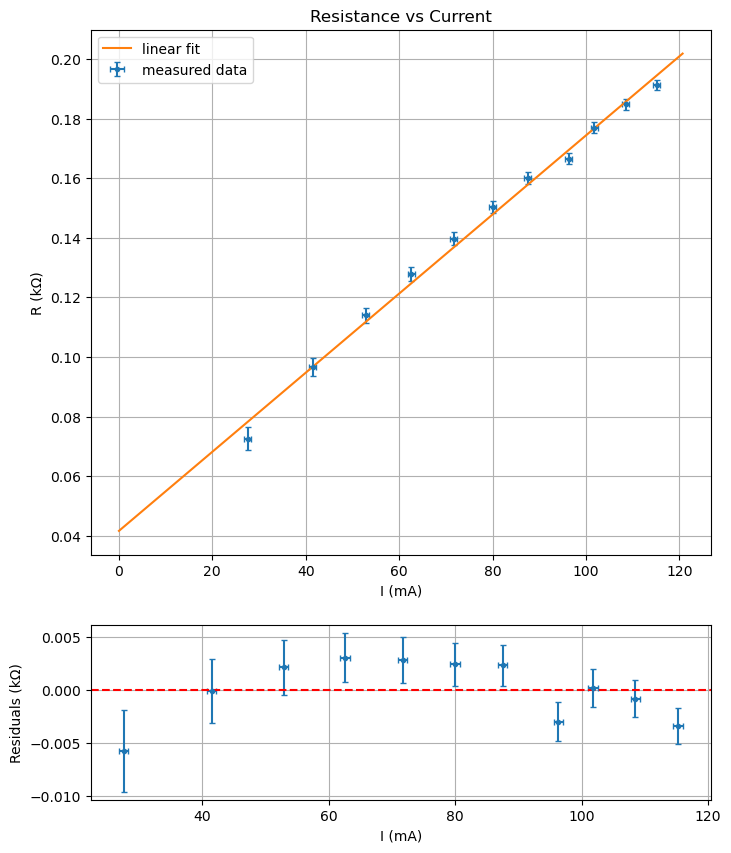

In [6]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# define linear model for fitting
def linear_model(x, k, R0):
    return k * x + R0


# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(linear_model, I[1:], R)
k_lin, R0_lin = coeff
dk_lin, dR0_lin = np.sqrt(np.diag(pcov))

# calculate R^2
R_pred = linear_model(I[1:], k_lin, R0_lin)

ss_res = np.sum((R - R_pred) ** 2)              # residual sum of squares
ss_tot = np.sum((R - np.mean(R)) ** 2)          # total sum of squares

r2 = 1 - (ss_res / ss_tot)

print(f"R^2 = {r2:.4f}")

from scipy import stats

# number of data points and parameters
n = len(R)
p = 2  # k and R0

# t-statistic for slope
t_stat = k_lin / dk_lin

# degrees of freedom
dof = n - p

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), dof))

print(f"Slope k = {k_lin:.4f} ± {dk_lin:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")



# calculate fitted values and residuals
I_range = np.linspace(0, max(I), 100)
R_fit = linear_model(I_range, k_lin, R0_lin)

res_lin = R - linear_model(I[1:], k_lin, R0_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(I[1:], R, xerr=dI, yerr=dR, fmt='.', capsize=2, label='measured data')
ax1.plot(I_range, R_fit, label='linear fit')
ax1.set_title('Resistance vs Current')
ax1.set_xlabel('I (mA)')
ax1.set_ylabel('R (kΩ)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(I[1:], res_lin, xerr=dI, yerr=dR, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('I (mA)')
ax2.set_ylabel('Residuals (kΩ)')
ax2.grid(True)
plt.show()

##### Discussion

Although not all points with the error bars are on the graph, we still have a strong positive correlation between R and I because our R^2 value is 0.9939 which is very close to 1. With the p-value << 0.05 the result is statistically significant and the null hypothesis is refuted. This means our data points are all well measured and there is a statistically significant correlation between current and resistance.

In [7]:
print(f"Linear fit parameters: k = ({k_lin*1000:.2f} ± {dk_lin*1000:.2f}) Ω/mA, R0 = ({R0_lin*1000:.0f} ± {dR0_lin*1000:.0f}) Ω")

Linear fit parameters: k = (1.33 ± 0.03) Ω/mA, R0 = (42 ± 3) Ω


#### Current vs Voltage

$R_L = R_0 + k \cdot I, V_L = R_L \cdot I = (R_0 + k I) \cdot I = R_0 I + k I^2 => I = \frac{-R_0 +- \sqrt{R_0^2 + 4k V_L}}{2 k}$

chi2 = 13.80
dof = 10
p-value = 0.1822
r = 0.9925
t = 25.72
p-value = 1.812e-10


/tmp/ipykernel_7999/3569145290.py:8: RuntimeWarning: invalid value encountered in sqrt
  return (-R0 + np.sqrt(R0 * R0 + 4 * k * x)) / (2 * k)


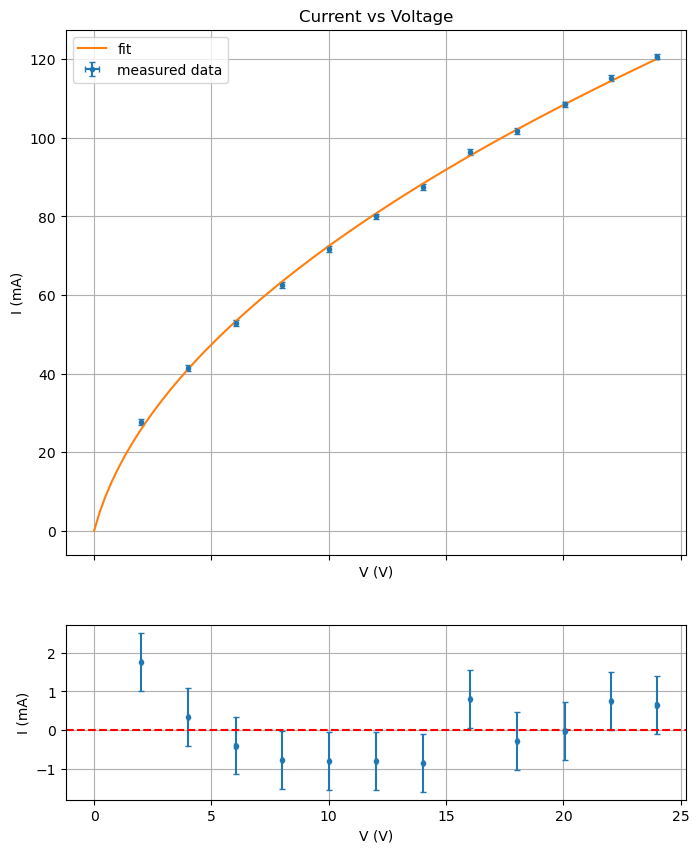

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from scipy.stats import chi2 as chi2_dist

def sqrt_model(x, k, R0):
    return (-R0 + np.sqrt(R0 * R0 + 4 * k * x)) / (2 * k)

# ---------------------------
# FIT
# ---------------------------
popt, pcov = curve_fit(sqrt_model, V, I)
k_sqrt, R0_sqrt = popt
dk_sqrt, dR0_sqrt = np.sqrt(np.diag(pcov))

# ---------------------------
# CHI-SQUARE TEST
# ---------------------------
chi2 = np.sum(((I - sqrt_model(V, k_sqrt, R0_sqrt)) / dI) ** 2)

dof = len(I) - len(popt)
p_value = 1 - chi2_dist.cdf(chi2, dof)

print(f"chi2 = {chi2:.2f}")
print(f"dof = {dof}")
print(f"p-value = {p_value:.4f}")

# ---------------------------
# CORRELATION (Pearson)
# ---------------------------
r, p_corr = pearsonr(V, I)

n = len(V)
t_corr = r * np.sqrt((n - 2) / (1 - r**2))

print(f"r = {r:.4f}")
print(f"t = {t_corr:.2f}")
print(f"p-value = {p_corr:.4g}")

# ---------------------------
# FIT CURVE + RESIDUALS
# ---------------------------
V_range = np.linspace(0, max(V), 100)
I_fit = sqrt_model(V_range, k_sqrt, R0_sqrt)
res_sqrt = I - sqrt_model(V, k_sqrt, R0_sqrt)

# ---------------------------
# PLOT
# ---------------------------
fig, ax = plt.subplots(
    2, 1, figsize=(8, 10),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)

ax1, ax2 = ax

# main plot
ax1.errorbar(V, I, xerr=dV, yerr=dI, fmt='.', capsize=2, label='measured data')
ax1.plot(V_range, I_fit, label='fit')
ax1.set_title('Current vs Voltage')
ax1.set_xlabel('V (V)')
ax1.set_ylabel('I (mA)')
ax1.grid(True)
ax1.legend()

# residuals
ax2.errorbar(V, res_sqrt, xerr=dV, yerr=dI, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('V (V)')
ax2.set_ylabel('I (mA)')
ax2.grid(True)

plt.show()

##### Discussion
We plotted the current vs. voltage graph and with the help of a t test we found out that there is a strong positiv correlation between the current and the voltage as r is close to 1 and the p-value again << 0.05. Afterwards we did a χ² goodness-of-fit test which gave us a p-value of ~0.18 which means that the square root model is an acceptable fit. If we would increase the error bars the p-value would increase too. From that we can follow that either our error bars are too small or we didn't messure the data precisly.

In [9]:
print(f"square root fit parameters: k = ({k_sqrt*1000:.2f} ± {dk_sqrt*1000:.2f}) Ω/mA, R0 = ({R0_sqrt*1000:.0f} ± {dR0_sqrt*1000:.0f}) Ω")

square root fit parameters: k = (1.30 ± 0.03) Ω/mA, R0 = (44 ± 3) Ω


### Series circuit

$I = \frac{-R_0 + \sqrt{R_0^2 + 4k V_L}}{2 k} = \frac {V_0 - V_L} R$

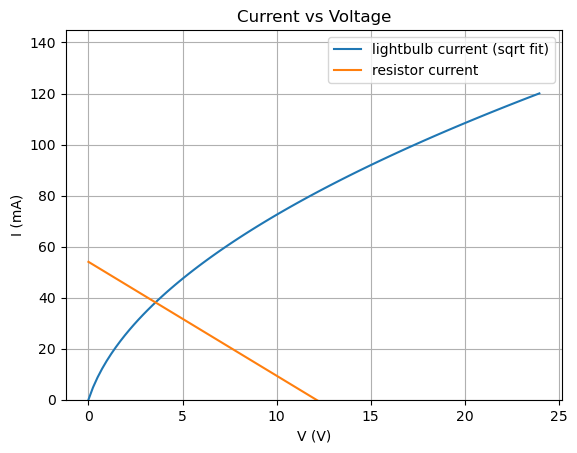

In [10]:
V0 = 3.54 + 8.57 # total voltage in V
R = 0.2241 # resistance of resistor in kohms

from scipy.optimize import fsolve

# define equation whose root is the intersection
def intersection_eq(V):
    return sqrt_model(V, k_sqrt, R0_sqrt) - (V0 - V) / R

# initial guess (pick something in your V range)
V_guess = V0 / 2

# solve
V_intersect = fsolve(intersection_eq, V_guess)[0]

# corresponding current
I_intersect = sqrt_model(V_intersect, k_sqrt, R0_sqrt)


V_range = np.linspace(0, max(V), 100)

IL = sqrt_model(V_range, k_sqrt, R0_sqrt) # define square root fit for current through the lightbulb
IR = (V0 - V_range) / R # define current through the resistor using Ohm's law

fig, ax = plt.subplots()
ax.plot(V_range, IL, label='lightbulb current (sqrt fit)')
ax.plot(V_range, IR, label='resistor current')
ax.set_title('Current vs Voltage')
ax.set_xlabel('V (V)')
ax.set_ylabel('I (mA)')
ax.set_ylim(0, max(I)*1.2)
ax.grid(True)
ax.legend()


Intersection at y = ~38.1mA is very close to the measured current of 38.3mA. This is expected, as the intersection point is the point where the currents are the same. With the help of the current through the resistor we can calculate the partial voltage across the resistor. The partial voltage across the light bulb is the total voltage minus the partial voltage across the resistor.

In [11]:
from scipy.optimize import root_scalar


def current_diff(V, k, R0, V0, R):
    # return current through lightbulb minus current resistor
    return sqrt_model(V, k, R0) - (V0 - V) / R

x0 = 3.6 # add initial guess for voltage across the lightbulb when currents are equal, based on the plot

sol = root_scalar(current_diff, args=(k_sqrt, R0_sqrt, V0, R), x0=x0)
VL_num = sol.root
IL_num = sqrt_model(VL_num, k_sqrt, R0_sqrt)
IR_num = (V0 - VL_num) / R

print(f"Voltage across the lightbulb when currents are equal: {VL_num:.2f} V")
print(f"Current through the lightbulb at this voltage: {IL_num:.2f} mA")
print(f"Current through the resistor at this voltage: {IR_num:.2f} mA")

Voltage across the lightbulb when currents are equal: 3.56 V
Current through the lightbulb at this voltage: 38.13 mA
Current through the resistor at this voltage: 38.13 mA


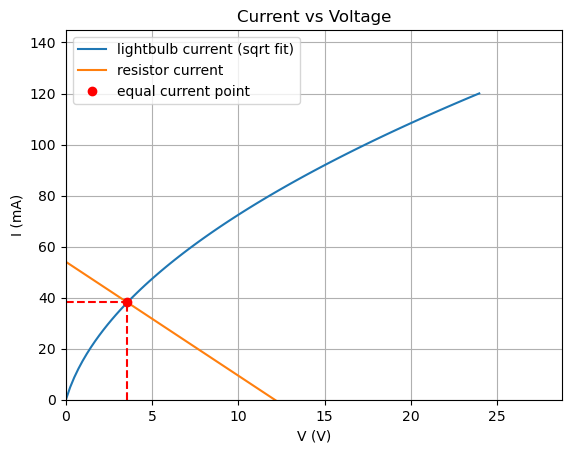

In [12]:
fig, ax = plt.subplots()
ax.plot(V_range, IL, label='lightbulb current (sqrt fit)')
ax.plot(V_range, IR, label='resistor current')
ax.plot(VL_num, IL_num, 'ro', label='equal current point')
ax.hlines(IL_num, 0, VL_num, color='red', linestyle='--')
ax.vlines(VL_num, 0, IL_num, color='red', linestyle='--')
ax.set_title('Current vs Voltage')
ax.set_xlabel('V (V)')
ax.set_ylabel('I (mA)')
ax.set_ylim(0, max(I)*1.2)
ax.set_xlim(0, max(V)*1.2)
ax.grid(True)
ax.legend()

plt.show()

In [13]:
V0 = 12.1 # total voltage in V
R = np.array([0.0992, 0.1512, 0.2241, 0.4720, 0.679]) # resistance of resistor in kohms
eI = np.array([])

V_range = np.linspace(0, max(V), 100)

IL = sqrt_model(V_range, k_sqrt, R0_sqrt) # define square root fit for current through the lightbulb
for r in R:
    IR = (V0 - V_range) / r # define current through the resistor using Ohm's law
    sol = root_scalar(current_diff, args=(k_sqrt, R0_sqrt, V0, r), x0=x0)
    VL_num = sol.root
    IL_num = sqrt_model(VL_num, k_sqrt, R0_sqrt)
    IR_num = (V0 - VL_num) / r
    VR= V0-VL_num
    print(f"For resistance {r}:")
    print(f"Volatge across the resistor when currents are equal: {VR:.2f} V" )
    print(f"Voltage: {VL_num:.2f} V")
    print(f"Current lightbulb = {IL_num:.2f} = current resistor = {IR_num:.2f} mA")
    print("")

For resistance 0.0992:
Volatge across the resistor when currents are equal: 5.56 V
Voltage: 6.54 V
Current lightbulb = 56.05 = current resistor = 56.05 mA

For resistance 0.1512:
Volatge across the resistor when currents are equal: 7.14 V
Voltage: 4.96 V
Current lightbulb = 47.19 = current resistor = 47.19 mA

For resistance 0.2241:
Volatge across the resistor when currents are equal: 8.54 V
Voltage: 3.56 V
Current lightbulb = 38.11 = current resistor = 38.11 mA

For resistance 0.472:
Volatge across the resistor when currents are equal: 10.48 V
Voltage: 1.62 V
Current lightbulb = 22.21 = current resistor = 22.21 mA

For resistance 0.679:
Volatge across the resistor when currents are equal: 11.04 V
Voltage: 1.06 V
Current lightbulb = 16.26 = current resistor = 16.26 mA



### Comparison measured vs calculated data
As we compare the calculated to the measured values we get for the voltage across the light bulb and the reistor a MAE of 0.11V which is compared to the overall voltage of 12.1V a good deviation. We get a small negative bias for the voltage across the light bulb with the last two measurements being slightly smaller than the calculated values and a MAPE of 8.37%. As the voltage across the resistor is V_0 - V_L we get a positive bias and as the voltages are on average bigger than across the light bulb we get an even better MAPE of only 1.12%. 

### Additional Exercises
#### 1
After setting up and solving the appropriate system of equations, we get the following results for the example circuit.
![image](solution.jpeg)
#### 2
When current flows through a filament, it dissipates electrical power in the form of heat. For this we had the equation
$P = \Delta V \cdot I = R \cdot I^2$. During operation the radiated power ($\propto T^4$) is equal to this electrical power. We previously established that for metals like tungsten the resistance is proportional to temperature as long as it's not too close to the melting point, so we get the following:
$R \cdot I^2 \propto T^4 \propto R^4 => I \propto R^{\frac 3 2}$. According to these calculations, in a lightbulb the resistance of the filament is indeed _not_ proportional to current, but instead follows a power law. We have tried different approaches to get a linear proportionality, but have not been able to come to this conclusion without simplifications that would render the calculation inapplicable (for example assuming the main power dispersion is conduction).